In [2]:
import pandas as pd

seeds = [0,1,2,3,42]
JaccardIndexDict = {}
SpearmanCorr = {}
for seed in seeds:
    ji_df = pd.read_csv(f"NivoBenefit/Seed_{seed}/WeightedJaccardIndex_{seed}_NivoBenefit.csv")
    spearman_df = pd.read_csv(f"NivoBenefit/Seed_{seed}/Spearman_GSEA.csv")
    JaccardIndexDict[seed] = ji_df 
    SpearmanCorr[seed] = spearman_df

In [15]:
import math 

methods = ["Avatars K5","Avatars K10","CTGAN","Gaussian Copula","Synthpop"]
avatarsk5_jaccards = []
avatarsk10_jaccards = []
ctgan_jaccards = []
gaussian_jaccards = []
synthpop_jaccards = []

avatarsk5_spearman = []
avatarsk10_spearman = []
ctgan_spearman = []
gaussian_spearman = []
synthpop_spearman = []

for seed in seeds: 
    jaccards_list = JaccardIndexDict[seed]['SFS'].values.tolist()
    avatarsk5_jaccards.append(jaccards_list[0])
    avatarsk10_jaccards.append(jaccards_list[1])
    ctgan_jaccards.append(jaccards_list[2])
    gaussian_jaccards.append(jaccards_list[3])
    synthpop_jaccards.append(jaccards_list[4])

    spearmans = SpearmanCorr[seed]['Spearman_rho']
    pvalues = SpearmanCorr[seed]['p_value']

    if spearmans[0]>0:
        score = spearmans[0]*(-math.log10(pvalues[0]))
        # avatarsk5_spearman.append(spearmans[0])
        avatarsk5_spearman.append(score)
    else:
        avatarsk5_spearman.append(0)
        
    if spearmans[1]>0:
        score = spearmans[1]*(-math.log10(pvalues[1]))
        avatarsk10_spearman.append(score)
        # avatarsk10_spearman.append(spearmans[1])
    else:
        avatarsk10_spearman.append(0)
        
    if spearmans[2]>0:
        score = spearmans[2]*(-math.log10(pvalues[2]))
        # ctgan_spearman.append(spearmans[2])
        ctgan_spearman.append(score)
    else:
        ctgan_spearman.append(0)
        
    if spearmans[3]>0:
        score = spearmans[3]*(-math.log10(pvalues[3]))
        # gaussian_spearman.append(spearmans[3])
        gaussian_spearman.append(score)
    else:
        gaussian_spearman.append(0)

    if spearmans[4]>0:
        score = spearmans[4]*(-math.log10(pvalues[4]))
        # synthpop_spearman.append(spearmans[4])
        synthpop_spearman.append(score)
    else:
        synthpop_spearman.append(0)

JaccardsMap = [avatarsk5_jaccards, avatarsk10_jaccards, ctgan_jaccards, gaussian_jaccards, synthpop_jaccards]
SpearmanMap = [avatarsk5_spearman,avatarsk10_spearman,ctgan_spearman,gaussian_spearman,synthpop_spearman]

In [12]:
WJ_dict = {}
Spearman_dict = {}
for i, method in enumerate(methods):
    WJ_dict[method] = JaccardsMap[i]   
    Spearman_dict[method] = SpearmanMap[i] 

df_wji = pd.DataFrame(WJ_dict)
df_spearman = pd.DataFrame(Spearman_dict)

/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/Manuscript/ccRCC/NarrowUtility/GSEA/Stability.py:169: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


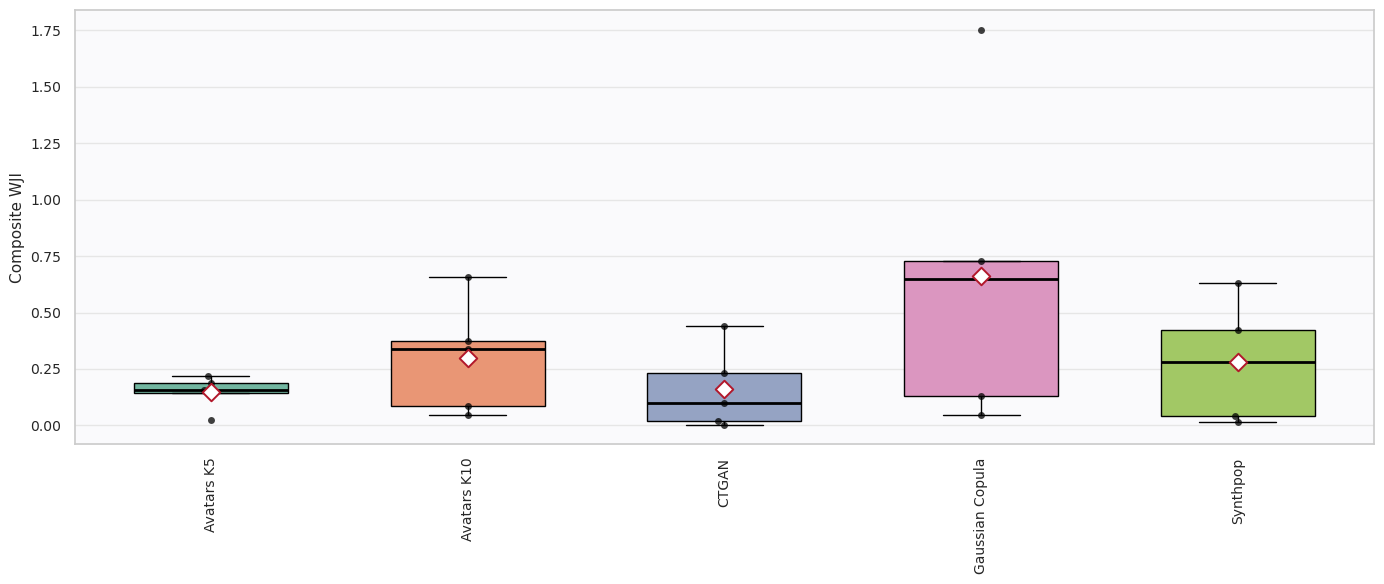

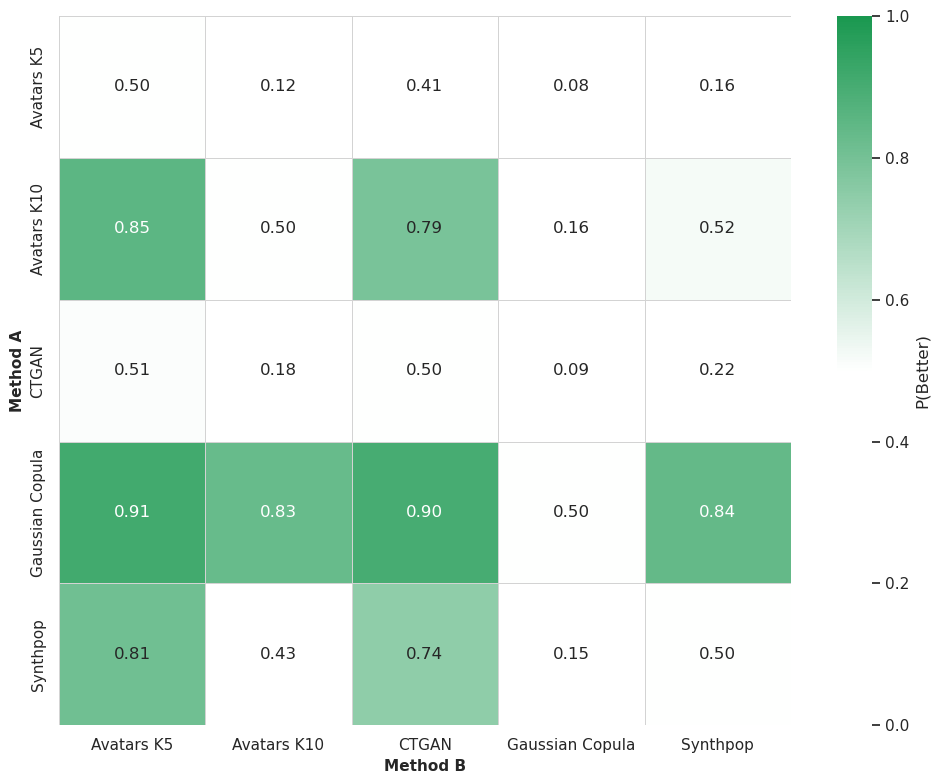

In [6]:
from Stability import wide_to_long, plot_box_swarm_with_mean, bayesian_estimation, pairwise_to_matrix, plot_pbetter_heatmap

df_long_wji= wide_to_long(df_wji, method_col="Method", value_col="Composite WJI")

# 2) Plot box+swarm and overlay mean markers (median stays as boxplot default)
wji_boxplot_fig,_,_ = plot_box_swarm_with_mean(
    df_long_wji,
    method_col="Method",
    value_col="Composite WJI",
    mean_style="diamond",  # or "line"
)
wji_boxplot_fig.savefig('Stability/GSEA_WJI_Stability.png', dpi = 300, bbox_inches='tight')
# 3) Bayesian pairwise probabilities (Benavoli-style, ROPE=0.01)
pairwise_wji = bayesian_estimation(df_wji, rope=0.01, n_samples=20_000, seed=0)
pairwise_wji.to_csv("Stability/Bayesian_WJI_GSEA.csv", index = False)
# 4) Convert to matrix and plot heatmap for P(Better)
pbetter_mat = pairwise_to_matrix(pairwise_wji, value_col="P(Better)", methods=df_spearman.columns, diag_value=0.5)
heatmap_wji, _ = plot_pbetter_heatmap(pbetter_mat, title = '')
heatmap_wji.savefig('Stability/Heatmap_WJI_GSEA.png', dpi = 300, bbox_inches='tight')

/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/Manuscript/ccRCC/NarrowUtility/GSEA/Stability.py:169: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


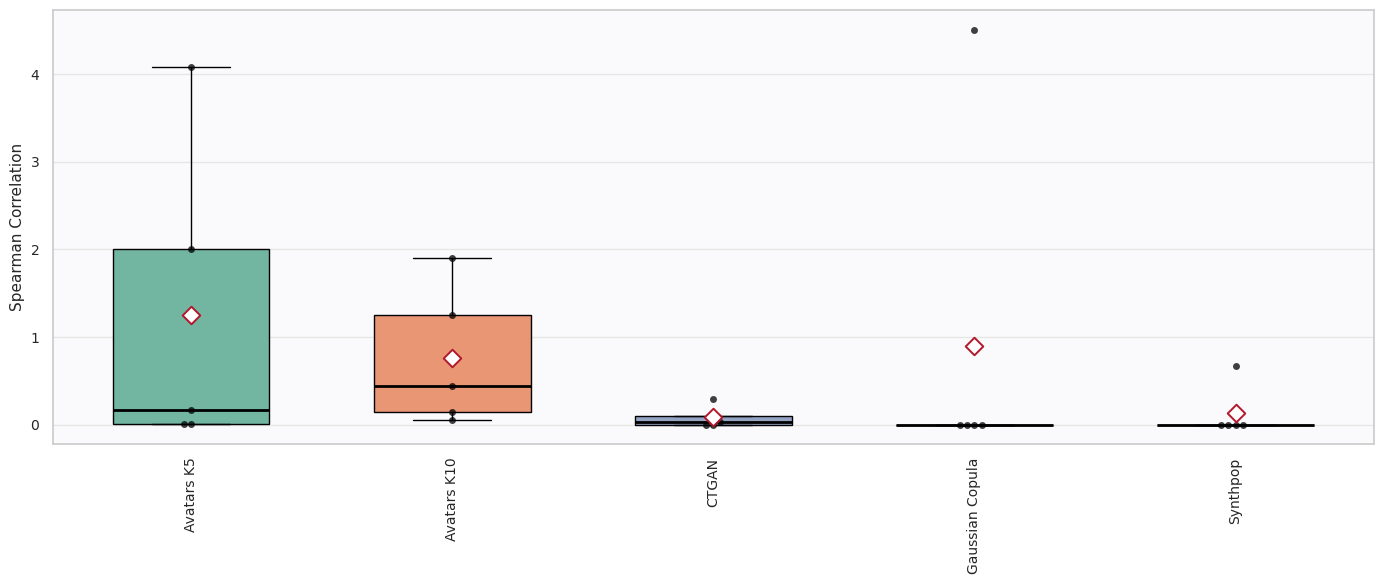

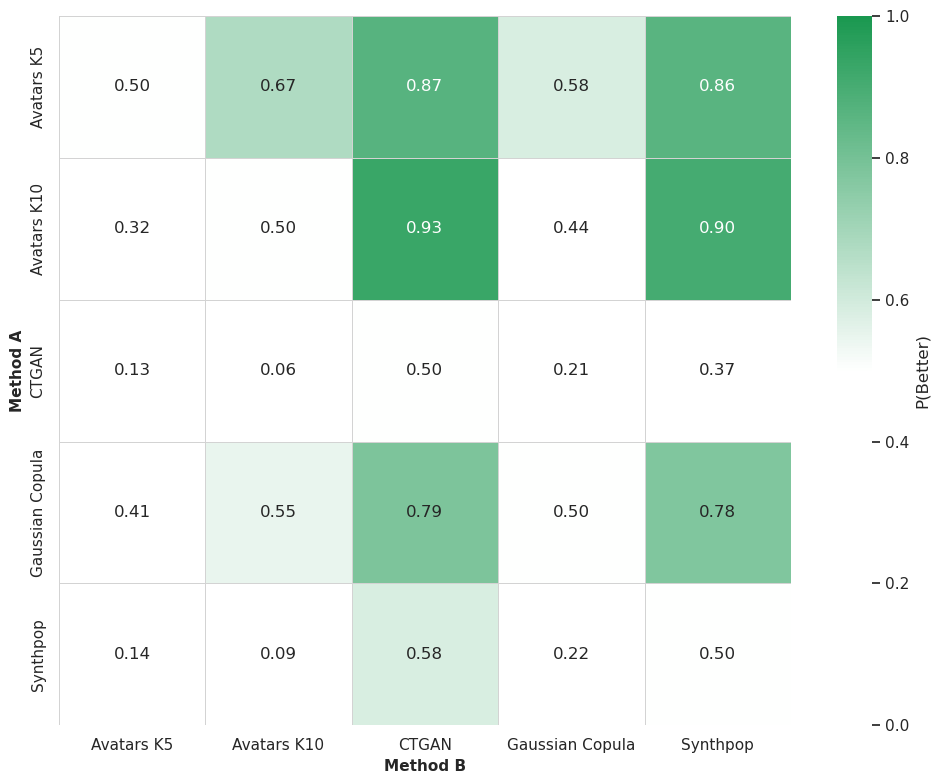

In [11]:
df_long_spearman = wide_to_long(df_spearman, method_col="Method", value_col="Spearman Correlation")

# 2) Plot box+swarm and overlay mean markers (median stays as boxplot default)
boxplot_fig, _, _ = plot_box_swarm_with_mean(
    df_long_spearman,
    method_col="Method",
    value_col="Spearman Correlation",
    mean_style="diamond",  # or "line"
)
boxplot_fig.savefig('Stability/GSEA_Spearman_Stability.png', dpi = 300, bbox_inches='tight')
# 3) Bayesian pairwise probabilities (Benavoli-style, ROPE=0.01)
pairwise = bayesian_estimation(df_spearman, rope=0.01, n_samples=1000, seed=42)
pairwise.to_csv("Stability/Bayesian_Spearman_GSEA.csv", index = False)
# 4) Convert to matrix and plot heatmap for P(Better)
pbetter_mat = pairwise_to_matrix(pairwise, value_col="P(Better)", methods=df_spearman.columns, diag_value=0.5)
heatmap_fig, heatmap_ax = plot_pbetter_heatmap(pbetter_mat, title = '')
heatmap_fig.savefig('Stability/Heatmap_Spearman_GSEA.png', dpi = 300, bbox_inches='tight')

In [8]:
df_spearman

,Avatars K5,Avatars K10,CTGAN,Gaussian Copula,Synthpop
0,0.203457,0.300168,0.164754,0.000000,0.000000
1,0.515294,0.127875,0.000000,0.000000,0.000000
2,0.643794,0.193085,0.000000,0.000000,0.000000
3,0.066507,0.439328,0.100504,0.000000,0.000000
4,0.047011,0.506363,0.255318,0.662617,0.350204
